# Capítulo 6, Sección 6.3 — Ejemplo 4 - Juan José Salazar Bedoya - Cristian Camilo Victoria Parra
## Source Term Inversion and Data Assimilation con PINNs

Este cuaderno replica el **Ejemplo 4** de la Sección 6.3: inversión de término fuente y asimilación de datos para una ecuación de Poisson estacionaria.

El planteamiento del libro es:

$
-\nabla^2 u(x)=f(x), \qquad x\in\Omega,
$

con condición de frontera

$
u(x)=g(x), \qquad x\in\partial\Omega.
$

En este problema inverso **no conocemos** el término fuente \(f\). Solo observamos valores dispersos de la solución:

$
u(x_d^i)=u_d^i.
$

La idea PINN del ejemplo es usar **dos redes neuronales**:

$
\widehat u(x;\theta)
$

para aproximar la solución, y

$
\widehat f(x;\phi)
$

para aproximar el término fuente desconocido.

La pérdida del libro tiene la forma:

$
L(\theta,\phi)
=
\lambda_f L_f(\theta,\phi)
+
\lambda_b L_b(\theta)
+
\lambda_d L_d(\theta),
$

donde

$
L_f=
\frac{1}{N_f}
\sum_{i=1}^{N_f}
\left|
-\nabla^2 \widehat u(x_f^i;\theta)
-
\widehat f(x_f^i;\phi)
\right|^2.
$

---

## Cierre numérico usado en este cuaderno

El libro describe el ejemplo de forma conceptual, pero no da todos los detalles computacionales necesarios para ejecutar un notebook completo. Para que el experimento sea reproducible, usamos el siguiente caso concreto:

$
\Omega=[0,1]^2,
\qquad
g=0 \text{ en } \partial\Omega.
$

El término fuente verdadero se toma como una fuente gaussiana centrada:

$
f_\star(x,y)
=
\exp\left(-\alpha\left((x-0.5)^2+(y-0.5)^2\right)\right).
$

El libro menciona una fuente gaussiana localizada como ejemplo. Aquí dejamos $\alpha$ configurable: si $\alpha=1$, se obtiene la forma literal amplia; si $\alpha$ es grande, la fuente queda más localizada.

Para generar datos observados $u_d$, resolvemos una vez el problema de Poisson con diferencias finitas. Esa solución de referencia **no se usa para entrenar la red**, excepto para extraer puntos observados dispersos.

In [ ]:
# ============================================================
# 1. Importaciones y configuración
# ============================================================

import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from scipy.sparse import diags, kron, eye
from scipy.sparse.linalg import spsolve
from scipy.interpolate import RegularGridInterpolator

np.random.seed(11)
torch.manual_seed(11)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("Dispositivo:", device)

PyTorch: 2.11.0+cpu
Dispositivo: cpu


## 2. Parámetros del experimento

- `ALPHA_SOURCE` controla qué tan localizada es la fuente gaussiana.
- `N_D = 20` replica la idea del libro: pocos datos observados.
- `N_f` son puntos de colocación interiores para imponer la EDP.
- `N_b_edge` son puntos por lado para imponer la frontera.

In [ ]:
# ============================================================
# 2. Hiperparámetros
# ============================================================

# Fuente gaussiana: f(x,y)=exp(-alpha*((x-0.5)^2+(y-0.5)^2))
# alpha=1 es la forma amplia escrita en el libro.
# alpha=80 muestra mejor una fuente localizada.
ALPHA_SOURCE = 80.0

# Número de datos observados dispersos
N_D = 20

# Puntos de colocación para el residuo físico
N_f = 5000

# Puntos de frontera por lado
N_b_edge = 350

# Malla de referencia para generar datos y validar
N_ref = 91

# Entrenamiento
N_STEPS = 10000 if device.type == "cuda" else 3000
PRINT_EVERY = max(300, N_STEPS // 7)

# Pesos de pérdida
lambda_f = 1.0
lambda_b = 100.0
lambda_d = 1000.0

# Arquitectura
WIDTH_U = 64
WIDTH_F = 64
DEPTH_U = 4
DEPTH_F = 4

# Fourier features ayudan a representar fuentes localizadas.
USE_FOURIER_FEATURES = True
FOURIER_FREQS = (1, 2, 4, 8)

print("N_STEPS =", N_STEPS)

N_STEPS = 3000


## 3. Fuente verdadera y solucionador de referencia

La PINN no conoce $f_\star$. Esta función solo se usa para:

1. generar una solución de referencia,
2. crear datos observados dispersos,
3. evaluar si la fuente reconstruida por la red se parece a la verdadera.

La solución de referencia se obtiene resolviendo

$
-\Delta u=f_\star
$

con diferencias finitas en una malla cuadrada y frontera homogénea.

In [ ]:
# ============================================================
# 3. Fuente verdadera y solver de Poisson por diferencias finitas
# ============================================================

def f_true_np(x, y, alpha=ALPHA_SOURCE):
    return np.exp(-alpha*((x - 0.5)**2 + (y - 0.5)**2))

def solve_poisson_fd(n=91):
    """
    Resuelve -Delta u = f en (0,1)^2 con u=0 en la frontera.
    Usa diferencias finitas de 5 puntos sobre puntos interiores.
    """
    x = np.linspace(0, 1, n)
    y = np.linspace(0, 1, n)
    h = x[1] - x[0]

    xi = x[1:-1]
    yi = y[1:-1]
    X_i, Y_i = np.meshgrid(xi, yi, indexing="xy")
    rhs = f_true_np(X_i, Y_i).reshape(-1)

    m = n - 2
    T = diags([-np.ones(m-1), 2*np.ones(m), -np.ones(m-1)], [-1, 0, 1], format="csr")
    I = eye(m, format="csr")

    # Matriz para -Delta: (kron(I,T)+kron(T,I))/h^2
    A = (kron(I, T) + kron(T, I)) / h**2

    u_inner = spsolve(A, rhs)
    U = np.zeros((n, n))
    U[1:-1, 1:-1] = u_inner.reshape(m, m)

    X, Y = np.meshgrid(x, y, indexing="xy")
    F = f_true_np(X, Y)
    return x, y, X, Y, U, F

x_ref, y_ref, X_ref, Y_ref, U_ref, F_ref = solve_poisson_fd(N_ref)

u_interp = RegularGridInterpolator(
    (y_ref, x_ref),
    U_ref,
    bounds_error=False,
    fill_value=None
)

print("Referencia lista.")
print("U_ref:", U_ref.shape, "F_ref:", F_ref.shape)
print("u max =", U_ref.max(), "| f max =", F_ref.max())

Referencia lista.
U_ref: (91, 91) F_ref: (91, 91)
u max = 0.011646387855558042 | f max = 1.0


## 4. Visualización del problema directo de referencia

Esto no es entrenamiento. Solo sirve para entender qué datos estamos intentando asimilar.

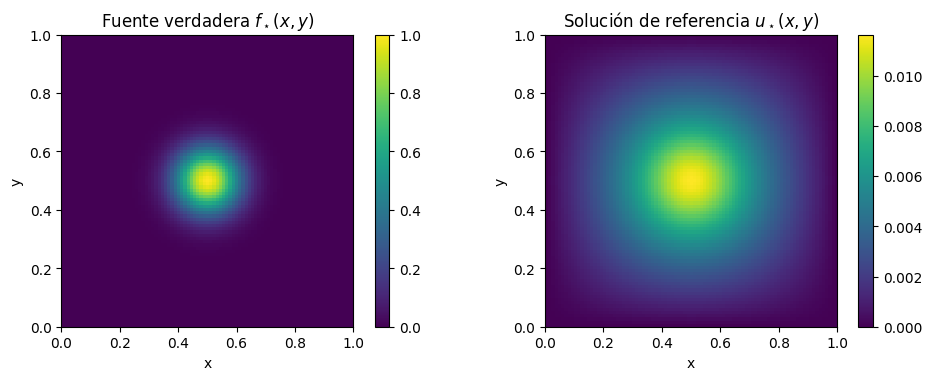

In [ ]:
# ============================================================
# 4. Visualización inicial
# ============================================================

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8))

im0 = axs[0].imshow(F_ref, origin="lower", extent=[0, 1, 0, 1], cmap="viridis")
axs[0].set_title(r"Fuente verdadera $f_\star(x,y)$")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(U_ref, origin="lower", extent=[0, 1, 0, 1], cmap="viridis")
axs[1].set_title(r"Solución de referencia $u_\star(x,y)$")
axs[1].set_xlabel("x")
axs[1].set_ylabel("y")
fig.colorbar(im1, ax=axs[1])

plt.tight_layout()
plt.show()

## 5. Datos observados y puntos de entrenamiento

Generamos tres conjuntos:

1. puntos interiores $x_f$ para imponer el residuo físico;
2. puntos de frontera $x_b$ para imponer $u=g$;
3. puntos observados $x_d$ donde se conoce $u_d$.

La red **solo ve** $u_d$ en `N_D=20` puntos. No ve la fuente verdadera.

In [ ]:
# ============================================================
# 5. Muestreo de puntos: interior, frontera y datos observados
# ============================================================

def to_col(a, requires_grad=False):
    t = torch.tensor(a, dtype=torch.float32, device=device).reshape(-1, 1)
    return t.requires_grad_(requires_grad)

# Puntos interiores para el residuo
xf = np.random.rand(N_f)
yf = np.random.rand(N_f)

# Puntos de frontera: cuatro lados del cuadrado
s = np.random.rand(N_b_edge)
xb = np.concatenate([
    np.zeros(N_b_edge),
    np.ones(N_b_edge),
    s,
    s
])
yb = np.concatenate([
    s,
    s,
    np.zeros(N_b_edge),
    np.ones(N_b_edge)
])
ub = np.zeros_like(xb)

# Datos observados dispersos
xd = np.random.rand(N_D)
yd = np.random.rand(N_D)
ud = u_interp(np.column_stack([yd, xd]))

# Tensores PyTorch
x_f = to_col(xf, requires_grad=True)
y_f = to_col(yf, requires_grad=True)

x_b = to_col(xb)
y_b = to_col(yb)
u_b = to_col(ub)

x_d = to_col(xd)
y_d = to_col(yd)
u_d = to_col(ud)

print("Puntos interiores:", x_f.shape[0])
print("Puntos frontera:", x_b.shape[0])
print("Datos observados:", x_d.shape[0])

Puntos interiores: 5000
Puntos frontera: 1400
Datos observados: 20


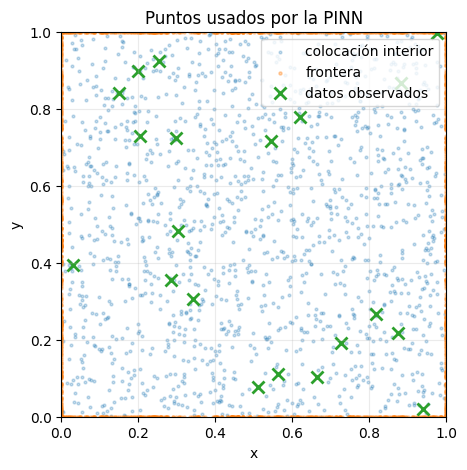

In [ ]:
# ============================================================
# 6. Visualización de puntos de entrenamiento
# ============================================================

plt.figure(figsize=(5.2, 5))
plt.scatter(xf[:1500], yf[:1500], s=4, alpha=0.25, label="colocación interior")
plt.scatter(xb, yb, s=5, alpha=0.35, label="frontera")
plt.scatter(xd, yd, s=75, marker="x", linewidths=2, label="datos observados")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.gca().set_aspect("equal")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Puntos usados por la PINN")
plt.legend(loc="upper right")
plt.grid(alpha=0.25)
plt.show()

## 6. Redes neuronales

Usamos dos MLPs:

$
\widehat u(x,y;\theta)
$

y

$
\widehat f(x,y;\phi).
$

La primera aproxima el campo solución.  
La segunda aproxima la fuente desconocida.

Ambas reciben coordenadas $(x,y)$. Si `USE_FOURIER_FEATURES=True`, las coordenadas se enriquecen con senos y cosenos para que las redes representen mejor estructuras localizadas.

In [ ]:
# ============================================================
# 7. Definición de redes
# ============================================================

class FourierEncoder(nn.Module):
    def __init__(self, freqs=(1, 2, 4, 8), use_fourier=True):
        super().__init__()
        self.use_fourier = use_fourier
        self.register_buffer(
            "freqs",
            torch.tensor(freqs, dtype=torch.float32).reshape(1, -1)
        )

    @property
    def out_dim(self):
        if not self.use_fourier:
            return 2
        return 2 + 4 * self.freqs.numel()

    def forward(self, x, y):
        if not self.use_fourier:
            return torch.cat([x, y], dim=1)

        sx = torch.sin(2*np.pi*x*self.freqs)
        cx = torch.cos(2*np.pi*x*self.freqs)
        sy = torch.sin(2*np.pi*y*self.freqs)
        cy = torch.cos(2*np.pi*y*self.freqs)

        return torch.cat([x, y, sx, cx, sy, cy], dim=1)


class MLP(nn.Module):
    def __init__(self, out_dim=1, width=64, depth=4, use_fourier=True, freqs=(1,2,4,8)):
        super().__init__()
        self.encoder = FourierEncoder(freqs=freqs, use_fourier=use_fourier)
        in_dim = self.encoder.out_dim

        dims = [in_dim] + [width]*depth + [out_dim]

        layers = []
        for i in range(len(dims)-1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims)-2:
                layers.append(nn.Tanh())

        self.net = nn.Sequential(*layers)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, y):
        z = self.encoder(x, y)
        return self.net(z)


u_net = MLP(width=WIDTH_U, depth=DEPTH_U, use_fourier=USE_FOURIER_FEATURES, freqs=FOURIER_FREQS).to(device)
f_net = MLP(width=WIDTH_F, depth=DEPTH_F, use_fourier=USE_FOURIER_FEATURES, freqs=FOURIER_FREQS).to(device)

n_params_u = sum(p.numel() for p in u_net.parameters() if p.requires_grad)
n_params_f = sum(p.numel() for p in f_net.parameters() if p.requires_grad)

print("Parámetros u_net:", n_params_u)
print("Parámetros f_net:", n_params_f)
print("Parámetros totales:", n_params_u + n_params_f)

Parámetros u_net: 13761
Parámetros f_net: 13761
Parámetros totales: 27522


## 7. Residuo físico por diferenciación automática

El residuo usado por el Ejemplo 4 es:

$
r(x,y)=
-\nabla^2 \widehat u(x,y;\theta)
-
\widehat f(x,y;\phi).
$

En dos variables:

$
\nabla^2 \widehat u
=
\widehat u_{xx}+\widehat u_{yy}.
$

PyTorch calcula estas derivadas con `autograd`.

In [ ]:
# ============================================================
# 8. Autograd y residuo físico
# ============================================================

def grad(outputs, inputs):
    return torch.autograd.grad(
        outputs,
        inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True
    )[0]


def poisson_source_residual(u_model, f_model, x, y):
    u = u_model(x, y)

    u_x = grad(u, x)
    u_y = grad(u, y)

    u_xx = grad(u_x, x)
    u_yy = grad(u_y, y)

    f_hat = f_model(x, y)

    residual = -(u_xx + u_yy) - f_hat
    return residual

## 8. Función de pérdida

La pérdida une tres ideas:

1. **EDP:** $-\Delta \widehat u$ debe coincidir con $\widehat f$.
2. **Frontera:** $\widehat u=g$ en $\partial\Omega$.
3. **Datos:** $\widehat u(x_d,y_d)$ debe coincidir con las observaciones $u_d$.

No se usa supervisión directa sobre la fuente. La fuente se reconstruye indirectamente.

In [ ]:
# ============================================================
# 9. Pérdida
# ============================================================

def loss_terms():
    r = poisson_source_residual(u_net, f_net, x_f, y_f)
    loss_f = (r**2).mean()

    loss_b = ((u_net(x_b, y_b) - u_b)**2).mean()

    loss_d = ((u_net(x_d, y_d) - u_d)**2).mean()

    total = lambda_f*loss_f + lambda_b*loss_b + lambda_d*loss_d
    return total, loss_f, loss_b, loss_d

## 9. Entrenamiento

Entrenamos simultáneamente los parámetros de las dos redes:

$
\theta \quad \text{y} \quad \phi.
$

Esto es lo esencial del ejemplo: el problema inverso se vuelve una sola optimización diferenciable.

In [ ]:
# ============================================================
# 10. Entrenamiento con Adam
# ============================================================

params = list(u_net.parameters()) + list(f_net.parameters())
optimizer = torch.optim.Adam(params, lr=1e-3)

hist = {
    "total": [],
    "pde": [],
    "bc": [],
    "data": []
}

t0 = time.time()

for it in range(N_STEPS + 1):
    optimizer.zero_grad(set_to_none=True)

    loss, loss_f, loss_b, loss_d = loss_terms()
    loss.backward()
    optimizer.step()

    hist["total"].append(float(loss.detach().cpu()))
    hist["pde"].append(float((lambda_f*loss_f).detach().cpu()))
    hist["bc"].append(float((lambda_b*loss_b).detach().cpu()))
    hist["data"].append(float((lambda_d*loss_d).detach().cpu()))

    if it % PRINT_EVERY == 0:
        print(
            f"it={it:5d} | "
            f"total={hist['total'][-1]:.3e} | "
            f"lambda_f L_f={hist['pde'][-1]:.3e} | "
            f"lambda_b L_b={hist['bc'][-1]:.3e} | "
            f"lambda_d L_d={hist['data'][-1]:.3e}"
        )

print("Tiempo de entrenamiento:", round(time.time() - t0, 2), "s")

it=    0 | total=3.663e+05 | lambda_f L_f=3.661e+05 | lambda_b L_b=8.470e+00 | lambda_d L_d=1.268e+02
it=  428 | total=1.134e+02 | lambda_f L_f=1.129e+02 | lambda_b L_b=4.679e-02 | lambda_d L_d=3.708e-01
it=  856 | total=3.506e+01 | lambda_f L_f=3.477e+01 | lambda_b L_b=2.193e-02 | lambda_d L_d=2.661e-01
it= 1284 | total=1.500e+01 | lambda_f L_f=1.482e+01 | lambda_b L_b=1.303e-02 | lambda_d L_d=1.752e-01
it= 1712 | total=7.081e+00 | lambda_f L_f=6.963e+00 | lambda_b L_b=8.268e-03 | lambda_d L_d=1.097e-01
it= 2140 | total=3.763e+00 | lambda_f L_f=3.689e+00 | lambda_b L_b=5.851e-03 | lambda_d L_d=6.798e-02
it= 2568 | total=2.292e+00 | lambda_f L_f=2.239e+00 | lambda_b L_b=4.864e-03 | lambda_d L_d=4.792e-02
it= 2996 | total=1.513e+00 | lambda_f L_f=1.474e+00 | lambda_b L_b=4.340e-03 | lambda_d L_d=3.563e-02
Tiempo de entrenamiento: 549.31 s


## 10. Validación

Comparamos:

$
\widehat u \quad \text{contra} \quad u_\star
$

y

$
\widehat f \quad \text{contra} \quad f_\star.
$

La comparación con $f_\star$ no forma parte del entrenamiento; es solo para saber si el problema inverso funcionó.

In [ ]:
# ============================================================
# 11. Evaluación en malla
# ============================================================

n_eval = 121
xe = np.linspace(0, 1, n_eval)
ye = np.linspace(0, 1, n_eval)
XE, YE = np.meshgrid(xe, ye, indexing="xy")

U_true = u_interp(np.column_stack([YE.ravel(), XE.ravel()])).reshape(n_eval, n_eval)
F_true = f_true_np(XE, YE)

with torch.no_grad():
    x_eval = to_col(XE.ravel())
    y_eval = to_col(YE.ravel())

    U_pred = u_net(x_eval, y_eval).detach().cpu().numpy().reshape(n_eval, n_eval)
    F_pred = f_net(x_eval, y_eval).detach().cpu().numpy().reshape(n_eval, n_eval)

err_u = np.abs(U_pred - U_true)
err_f = np.abs(F_pred - F_true)

rel_l2_u = np.sqrt(np.mean((U_pred - U_true)**2)) / np.sqrt(np.mean(U_true**2))
rel_l2_f = np.sqrt(np.mean((F_pred - F_true)**2)) / np.sqrt(np.mean(F_true**2))

print("Error relativo L2 de u:", rel_l2_u)
print("Error relativo L2 de f:", rel_l2_f)
print("Error máximo de u:", err_u.max())
print("Error máximo de f:", err_f.max())

Error relativo L2 de u: 2.1462215940380682
Error relativo L2 de f: 46.23980012014415
Error máximo de u: 0.025170896572405496
Error máximo de f: 17.161694868745755


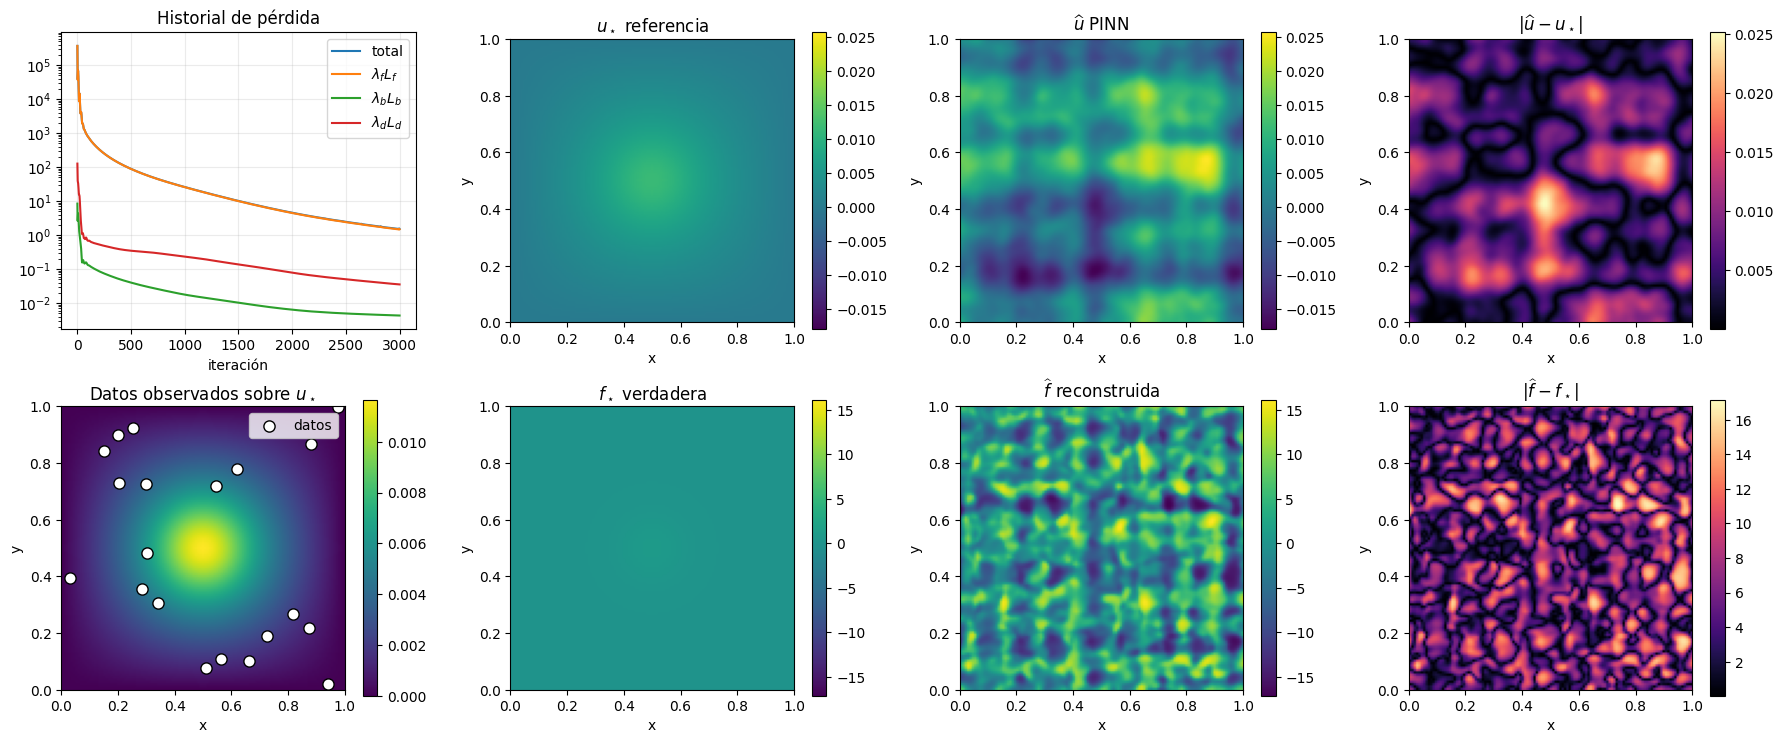

In [ ]:
# ============================================================
# 12. Gráficas finales
# ============================================================

fig, axs = plt.subplots(2, 4, figsize=(18, 7.5))

# Historial
axs[0, 0].semilogy(hist["total"], label="total")
axs[0, 0].semilogy(hist["pde"], label=r"$\lambda_f L_f$")
axs[0, 0].semilogy(hist["bc"], label=r"$\lambda_b L_b$")
axs[0, 0].semilogy(hist["data"], label=r"$\lambda_d L_d$")
axs[0, 0].set_title("Historial de pérdida")
axs[0, 0].set_xlabel("iteración")
axs[0, 0].grid(alpha=0.25)
axs[0, 0].legend()

# Datos observados
im = axs[1, 0].imshow(U_true, origin="lower", extent=[0,1,0,1], cmap="viridis")
axs[1, 0].scatter(xd, yd, s=65, c="white", edgecolors="black", marker="o", label="datos")
axs[1, 0].set_title("Datos observados sobre $u_\\star$")
axs[1, 0].set_xlabel("x")
axs[1, 0].set_ylabel("y")
axs[1, 0].legend(loc="upper right")
fig.colorbar(im, ax=axs[1, 0])

# Solución
vmin_u = min(U_true.min(), U_pred.min())
vmax_u = max(U_true.max(), U_pred.max())

im1 = axs[0, 1].imshow(U_true, origin="lower", extent=[0,1,0,1], cmap="viridis", vmin=vmin_u, vmax=vmax_u)
axs[0, 1].set_title(r"$u_\star$ referencia")
axs[0, 1].set_xlabel("x")
axs[0, 1].set_ylabel("y")
fig.colorbar(im1, ax=axs[0, 1])

im2 = axs[0, 2].imshow(U_pred, origin="lower", extent=[0,1,0,1], cmap="viridis", vmin=vmin_u, vmax=vmax_u)
axs[0, 2].set_title(r"$\widehat u$ PINN")
axs[0, 2].set_xlabel("x")
axs[0, 2].set_ylabel("y")
fig.colorbar(im2, ax=axs[0, 2])

im3 = axs[0, 3].imshow(err_u, origin="lower", extent=[0,1,0,1], cmap="magma")
axs[0, 3].set_title(r"$|\widehat u-u_\star|$")
axs[0, 3].set_xlabel("x")
axs[0, 3].set_ylabel("y")
fig.colorbar(im3, ax=axs[0, 3])

# Fuente
vmin_f = min(F_true.min(), F_pred.min())
vmax_f = max(F_true.max(), F_pred.max())

im4 = axs[1, 1].imshow(F_true, origin="lower", extent=[0,1,0,1], cmap="viridis", vmin=vmin_f, vmax=vmax_f)
axs[1, 1].set_title(r"$f_\star$ verdadera")
axs[1, 1].set_xlabel("x")
axs[1, 1].set_ylabel("y")
fig.colorbar(im4, ax=axs[1, 1])

im5 = axs[1, 2].imshow(F_pred, origin="lower", extent=[0,1,0,1], cmap="viridis", vmin=vmin_f, vmax=vmax_f)
axs[1, 2].set_title(r"$\widehat f$ reconstruida")
axs[1, 2].set_xlabel("x")
axs[1, 2].set_ylabel("y")
fig.colorbar(im5, ax=axs[1, 2])

im6 = axs[1, 3].imshow(err_f, origin="lower", extent=[0,1,0,1], cmap="magma")
axs[1, 3].set_title(r"$|\widehat f-f_\star|$")
axs[1, 3].set_xlabel("x")
axs[1, 3].set_ylabel("y")
fig.colorbar(im6, ax=axs[1, 3])

plt.tight_layout()
plt.show()

## 11. Chequeo del residuo físico en puntos nuevos

La pérdida puede bajar sin que la solución sea buena. Por eso evaluamos el residuo en puntos aleatorios nuevos no usados directamente para graficar.

In [ ]:
# ============================================================
# 13. Chequeo del residuo físico en puntos nuevos
# ============================================================

N_check = 3000
xc = np.random.rand(N_check)
yc = np.random.rand(N_check)

x_c = to_col(xc, requires_grad=True)
y_c = to_col(yc, requires_grad=True)

r_c = poisson_source_residual(u_net, f_net, x_c, y_c).detach().cpu().numpy().ravel()

rmse_r = np.sqrt(np.mean(r_c**2))
mae_r = np.mean(np.abs(r_c))

print("RMSE del residuo en puntos nuevos:", rmse_r)
print("MAE del residuo en puntos nuevos:", mae_r)

RMSE del residuo en puntos nuevos: 2.2995455
MAE del residuo en puntos nuevos: 1.6291708


## 12. Interpretación esperada

Si el entrenamiento funciona razonablemente:

- $L_d$ baja: la red ajusta los pocos datos observados.
- $L_b$ baja: la red respeta la frontera.
- $L_f$ baja: las redes $\widehat u$ y $\widehat f$ se vuelven compatibles con Poisson.
- $\widehat f$ debe recuperar al menos la localización y forma global de la fuente.

Este ejemplo es más delicado que el problema directo: reconstruir una función fuente desde pocos valores de $u$ es mucho más difícil que resolver una EDP con fuente conocida. Si `N_D=20` no basta para una reconstrucción limpia, aumente `N_D`, entrene más iteraciones o active una estrategia de muestreo adaptativo. El milagro de recuperar una función completa desde casi nada no viene incluido gratis, por muy PINN que suene.